# Optimal Battery Storage Dispatch under Stochastic Electricity Prices
## A Q-Learning Approach

### 1. Introduction

Electricity prices in wholesale markets fluctuate significantly across hours
and days, driven by variable renewable generation and demand shocks. A battery
storage operator faces a sequential decision problem: when to charge (buy cheap
electricity), when to discharge (sell at high prices), and when to remain idle
— all under uncertainty about future price dynamics.

This tutorial models the operator as a reinforcement learning (RL) agent that
learns an optimal dispatch policy through direct interaction with a stochastic
price environment, without requiring prior knowledge of the price transition
probabilities. I apply tabular Q-learning, an off-policy temporal-difference
control algorithm, to find the optimal action-value function and derive the
corresponding dispatch policy. To evaluate performance, I benchmark the
Q-learning solution against Value Iteration, which yields the theoretical
optimum using full knowledge of the transition matrix. The comparison shows
that Q-learning recovers 98.9% of the Value Iteration benchmark reward,
demonstrating that model-free reinforcement learning can effectively solve
this class of energy storage problems.

## 2. Economic Model

I model the battery operator's problem as a Markov Decision Process (MDP)
defined by the tuple $(S, A, r, P, \beta)$.

**State space.** The state at each period $t$ is a pair $s_t = (SoC_t, p_t)$, where
$SoC_t \in \{0, 1, \ldots, 10\}$ denotes the battery's state of charge in MWh, and
$p_t \in \{\text{Low, Mid, High}\}$ denotes the prevailing electricity price regime.
The state space contains $11 \times 3 = 33$ states.

**Action space.** The operator chooses $a_t \in \{-1, 0, +1\}$, corresponding to
discharging, idling, and charging by one MWh respectively. Actions are subject
to feasibility constraints: the battery cannot discharge when empty ($SoC = 0$)
or charge when full ($SoC = 10$). Note that $SoC$ does not enter the reward function
directly; its role is to determine the set of feasible actions available each period.

**Reward function.** The per-period reward is:

$$r(s_t, a_t) = -p_t \cdot a_t - c_{deg} \cdot |a_t|$$

where $p_t$ is the price level of the current regime and $c_{deg} = 2$ €/MWh is a
degradation cost applied whenever the battery is active. Discharging ($a_t = -1$)
yields revenue $p_t - c_{deg}$; charging ($a_t = +1$) incurs cost $p_t + c_{deg}$;
idling yields zero.

**Transition dynamics.** The SoC evolves deterministically:

$$SoC' = \text{clip}(SoC_t + a_t,\ 0,\ 10)$$

The price regime follows a first-order Markov chain with transition matrix:

$$P = \begin{pmatrix} 0.6 & 0.3 & 0.1 \\ 0.2 & 0.6 & 0.2 \\ 0.1 & 0.3 & 0.6 \end{pmatrix}$$

Rows and columns follow the order Low, Mid, High. Entry $P_{ij}$ is the
probability of transitioning from regime $i$ to regime $j$ in the next
period. For example, $P_{\text{Low,High}} = 0.1$ means that a Low-price
period is followed by a High-price period with probability 0.1. Diagonal
entries of 0.6 reflect price inertia; direct Low↔High transitions carry
the smallest probability of 0.1, reflecting the rarity of extreme price jumps.


**Bellman equation.** I derive the optimal action-value function Q* by
starting from the general RL Bellman equation (Exercise 26 in the course):

$$Q^*(s,a) = \sum_{s',r} p(s',r|s,a) \left[ r + \beta \cdot \max_{a'} Q^*(s',a') \right]$$

- $Q^*(s,a)$: the optimal action-value — the expected discounted return from
  taking action $a$ in state $s$ and acting optimally thereafter.
- $p(s',r|s,a)$: the joint probability of transitioning to next state $s'$
  and receiving reward $r$, given current state $s$ and action $a$.
- $r$: the immediate reward received after taking action $a$ in state $s$.
- $\beta$: the discount factor, which weights future rewards relative to
  immediate rewards.
- $\max_{a'} Q^*(s',a')$: the best possible Q-value achievable from the next
  state $s'$ — the continuation value under the optimal policy.
- $\sum_{s',r}$: expectation over all possible next states and rewards, since
  both $s'$ and $r$ may be stochastic.

I now substitute the specific structure of my model in three steps.

**Step 1: Reward is deterministic.** Given state $s = (SoC, p)$ and action $a$,
the reward $r(s,a) = -p \cdot a - c_{deg} \cdot |a|$ is fully determined. It does not
depend on the next state, so it can be pulled outside the expectation:

$$Q^*(s,a) = r(s,a) + \beta \cdot \sum_{s'} p(s'|s,a) \cdot \max_{a'} Q^*(s',a')$$

**Step 2: State transition splits into two independent parts.** The next
state $s' = (SoC', p')$ has two components. $SoC' = \text{clip}(SoC + a, 0, N)$
is deterministic — it follows directly from the action. Only the price $p'$ is
stochastic, governed by the Markov transition matrix $P(p'|p)$. Since the two
components are independent, the joint transition probability factorises as:

$$p(s'|s,a) = P(p'|p) \cdot \mathbf{1}\left[SoC' = \text{clip}(SoC + a, 0, N)\right]$$

where $P(p'|p)$ is the price transition probability and $\mathbf{1}[\cdot]$
is an indicator function that equals 1 if $SoC'$ takes its deterministic
value, and 0 otherwise.

**Step 3: Substitute into the equation.** Since $SoC'$ is determined by the
action, the sum over $s'$ reduces to a sum over $p'$ only. Substituting
$p(s'|s,a) = P(p'|p) \cdot \mathbf{1}[SoC' = \text{clip}(SoC + a, 0, N)]$
into the equation and inserting the reward function
$r(SoC, p, a) = -p \cdot a - c_{deg} \cdot |a|$:

$$Q^*(SoC, p, a) = \underbrace{-p \cdot a - c_{deg} \cdot |a|}_{\text{current payoff}} + \beta \cdot \underbrace{\sum_{p'} P(p'|p) \cdot \max_{a'} Q^*(SoC', p', a')}_{\text{continuation value}}$$

where $SoC' = \text{clip}(SoC + a, 0, N)$, $p \in \{30, 60, 100\}$ €/MWh,
$a \in \{-1, 0, +1\}$, $c_{deg} = 2$ €/MWh, and $\beta = 0.95$.

The first term is the current payoff: revenue from discharging or cost of
charging, net of degradation. The second term is the continuation value:
the discounted expected value of acting optimally from the next state
onward, where the expectation is taken exclusively over the stochastic
price transition $P(p'|p)$, since $SoC'$ is fully determined by the action.


## 3. Solution Method

I solve the MDP using **tabular Q-learning**, an off-policy temporal difference
(TD) control algorithm introduced by Watkins (1992). Q-learning learns the
optimal action-value function $Q^*$ directly from simulated experience, without
requiring knowledge of the transition matrix $P$.

**Why Q-learning and not SARSA?**

Both are TD methods, but they differ in how
they update Q-values. SARSA is on-policy: it updates using the action actually
taken next, including exploratory actions, and therefore learns a cautious policy
that accounts for exploration noise. Q-learning is off-policy: it always updates
using the best possible next action regardless of what the agent actually does,
and therefore learns the theoretically optimal policy directly. Since the goal is
to find the optimal dispatch policy rather than a policy that hedges against
exploration, Q-learning is the appropriate choice.

This distinction matters particularly for the battery dispatch problem. The
feasibility constraints: no discharge when $SoC = 0$, no charge when $SoC = 10$
 mean that exploratory actions near the boundaries are frequently infeasible
and must be filtered out. A SARSA agent would learn to be overly conservative
near these boundaries, avoiding states where random exploration might lead to
infeasible actions. A Q-learning agent, by contrast, always evaluates the best
feasible next action in its update, and therefore learns the true optimal
boundary behaviour regardless of what exploratory actions happen to be taken
during training.

Furthermore, SARSA is on-policy: with a fixed $\varepsilon$-greedy behaviour rule, it converges to the value of that exploratory policy rather than directly to the fully greedy optimum. Q-learning, by contrast, is off-policy and updates toward the value of the best next action. This makes it the more natural choice here, since the objective is to recover an approximately optimal dispatch policy rather than a policy that explicitly internalises ongoing exploration noise.

**Update rule.**

At each step, after observing reward $r$ and next state $s'$,
the Q-table is updated as:

$$Q'(s,a) \leftarrow Q(s,a) + \alpha \cdot \underbrace{\left[r + \beta \cdot \max_{a'} Q(s',a') - Q(s,a)\right]}_{\text{TD error } \delta}$$

where $Q'(s,a)$ denotes the updated estimate after observing the transition,
and $Q^*$ denotes the theoretical optimum that the algorithm converges to
over many episodes. The term in brackets is the TD error $\delta$: the
difference between the current estimate $Q(s,a)$ and the target
$r + \beta \cdot \max_{a'} Q(s',a')$. Over many episodes, repeated updates reduce the TD error and move the Q-table toward the optimal action-value function. In the present finite-sample implementation, the algorithm should therefore be interpreted as delivering an empirical approximation to $Q^*$, whose quality can be assessed by comparison with the Value Iteration benchmark.
**Pseudocode.**
```
Algorithm: Tabular Q-Learning for Battery Dispatch
───────────────────────────────────────────────────
Input:  α, β, ε, n_episodes, steps, N, prices, P
Output: Q*(s, a) for all s ∈ S, a ∈ A

Initialise Q(s, a) = 0 for all s, a

for episode = 1, ..., n_episodes do
    Initialise s = (SoC, price) randomly

    for step = 1, ..., steps do
        Determine feasible actions A(s)

        with probability ε:
            a ← random action from A(s)          // explore
        else:
            a ← argmax_a' Q(s, a')               // exploit

        Execute a, observe r and s'

        Q'(s,a) ← Q(s,a) + α·[r + β·max_a' Q(s',a') − Q(s,a)]

        s ← s'
    end for
end for
───────────────────────────────────────────────────
```

**Exploration strategy.**

I use an $\varepsilon$-greedy policy during training:
with probability $\varepsilon = 0.1$ the agent selects a random feasible action
(exploration), and with probability $1-\varepsilon$ it selects the action with
the highest Q-value (exploitation). The fixed $\varepsilon$ ensures all
state-action pairs continue to be visited throughout training, which is a
necessary condition for convergence of tabular Q-learning.

**Benchmark.**

To evaluate the quality of the learned policy, I additionally
solve the same MDP using Value Iteration (VI), which directly applies the Bellman
equation using full knowledge of $P$:

$$Q^{(i+1)}(SoC, p, a) = r(SoC, p, a) + \beta \sum_{p'} P(p'|p) \cdot \max_{a'} Q^{(i)}(SoC', p', a')$$

VI iterates until the maximum change across all Q-values falls below $10^{-6}$,
yielding the theoretical optimum $Q^*_{VI}$. Comparing the average reward per
step under the Q-learning policy and the VI policy provides a direct measure of
how close the model-free solution is to the theoretical optimum.

## 4. Numerical Implementation and Results

The model is implemented in Python using NumPy. The state space is represented
as a discrete grid: $SoC \in \{0, 1, \ldots, 10\}$ and $p \in \{\text{Low,
Mid, High}\}$, giving 33 states in total. The Q-table is stored as an
$11 \times 3 \times 3$ array initialised to zero, where the three dimensions
correspond to SoC, price regime, and action index respectively. At each step,
feasible actions are determined by the current SoC — discharge is excluded at
$SoC = 0$, charge at $SoC = 10$.

Q-learning runs for 100,000 episodes of 100 steps each. Each episode begins
from a randomly drawn state $(SoC, p)$ to ensure broad coverage of the state
space across episodes. The random seed is fixed at 42 for reproducibility.
Value Iteration iterates the Bellman equation over all 99 state-action pairs
using the known transition matrix $P$, stopping when the maximum change across
all Q-values falls below $10^{-6}$, which occurs after 314 iterations. All
algorithm parameters are summarised in the table below.

| Parameter | Value | Justification |
|---|---|---|
| Battery capacity $N$ | 10 MWh | Consistent with course exercises |
| Price levels $p$ | 30, 60, 100 €/MWh | Approximate Low/Mid/High ranges of German day-ahead wholesale prices |
| Transition matrix diagonal | 0.6 | Reflects price inertia; Low↔High jump probability 0.1 |
| Degradation cost $c_{deg}$ | 2 €/MWh | Within realistic range for Li-ion batteries (1–5 €/MWh); prevents trivial cycling |
| Discount factor $\beta$ | 0.95 | Standard for infinite-horizon problems; consistent with course exercises |
| Learning rate $\alpha$ | 0.1 | Standard for tabular Q-learning |
| Exploration rate $\varepsilon$ | 0.1 | Standard $\varepsilon$-greedy exploration |
| Episodes | 100,000 | Ensures sufficient state coverage |
| Steps per episode | 100 | Balances computational cost and experience diversity |
| **Total Q-table updates** | **10 million** | 100,000 × 100 |

Value Iteration uses the same Bellman equation with
known transition matrix P, iterating until the maximum change across all
Q-values falls below $10^{-6}$, which occurs after 314 iterations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# ── Battery parameters ──────────────────────────
N = 10          # maximum SoC (number of levels: 0..N)
c_deg = 2.0     # degradation cost per MWh charged/discharged (€/MWh)

# ── Price regimes ────────────────────────────────
prices = np.array([30,60,100])        # Low, Mid, High (€/MWh)

# ── Transition matrix ────────────────────────────
P = np.array([[0.6, 0.3, 0.1],     # Low  -> Low, Mid, High
        [0.2, 0.6, 0.2],     # Mid  -> Low, Mid, High
        [0.1, 0.3, 0.6]])    # High -> Low, Mid, High


# ── Algorithm parameters ─────────────────────────
alpha = 0.1    # learning rate
beta = 0.95   # discount factor
epsilon = 0.1    # exploration rate
n_episodes = 100000 # number of training episodes

In [2]:
def get_reward(soc, price_idx, action):
    p = prices[price_idx]
    return -p * action - c_deg * abs(action)  #Revenue from discharging minus cost of charging minus degradation.

def get_next_state(soc, price_idx, action):
    next_soc = int(np.clip(soc + action, 0, N))
    next_price = int(np.random.choice(3, p=P[price_idx]))
    return next_soc, next_price  #Transition to next (soc, price) state.

def get_valid_actions(soc):
  actions = [0]     # idle is always possible
  if soc > 0:
    actions.append(-1)  # discharge only if not empty
  if soc < N:
    actions.append(1)   # charge only if not full
  return actions

In [3]:
# ── Q-table ─────────────────────────────────────
actions = np.array([-1, 0, 1])          # action index 0=discharge, 1=idle, 2=charge
Q = np.zeros((N + 1, 3, len(actions)))  # Q[soc, price_regime, action_idx]

In [4]:
# ── Q-learning main loop ─────────────────────────
rewards_per_episode = []

for episode in range(n_episodes):

    # 1. initialise state randomly at start of each episode
    soc = np.random.randint(0, N + 1)
    price_idx = np.random.randint(0, 3)

    episode_reward = 0

    for step in range(100):   # max 100 steps per episode

        # 2. choose action (epsilon-greedy)
        valid = get_valid_actions(soc)
        valid_idx = [np.where(actions == a)[0][0] for a in valid]

        if np.random.random() < epsilon:
            action_idx = np.random.choice(valid_idx)      # explore
        else:
            q_vals = [Q[soc, price_idx, i] for i in valid_idx]
            action_idx = valid_idx[np.argmax(q_vals)]     # exploit

        action = actions[action_idx]

        # 3. take action, observe reward and next state
        reward = get_reward(soc, price_idx, action)
        next_soc, next_price = get_next_state(soc, price_idx, action)

        # 4. Q-learning update
        next_valid = get_valid_actions(next_soc)
        next_valid_idx = [np.where(actions == a)[0][0] for a in next_valid]
        best_next_q = max([Q[next_soc, next_price, i] for i in next_valid_idx])

        Q[soc, price_idx, action_idx] += alpha * (
            reward + beta * best_next_q - Q[soc, price_idx, action_idx]
        )

        episode_reward += reward
        soc, price_idx = next_soc, next_price

    rewards_per_episode.append(episode_reward)

In [5]:
# check Q-table is no longer all zeros
print("Max Q value:", Q.max().round(2))
print("Min Q value:", Q.min().round(2))
print("Q-table sample (SoC=5, Mid price):")
print("  discharge:", round(Q[5, 1, 0], 2))
print("  idle:     ", round(Q[5, 1, 1], 2))
print("  charge:   ", round(Q[5, 1, 2], 2))

Max Q value: 694.54
Min Q value: 0.0
Q-table sample (SoC=5, Mid price):
  discharge: 418.21
  idle:      406.48
  charge:    387.5


In [6]:
# ── Value Iteration ──────────────────────────────
N = 10
prices = np.array([30, 60, 100])
P = np.array([[0.6,0.3,0.1],[0.2,0.6,0.2],[0.1,0.3,0.6]])
beta = 0.95
c_deg = 2.0
actions = np.array([-1, 0, 1])
NEGINF = -1e9

Q_vi = np.zeros((N+1, 3, 3))
for iteration in range(10000):
    Q_old = Q_vi.copy()
    for soc in range(N+1):
        for price_idx in range(3):
            for ai, action in enumerate(actions):
                valid = get_valid_actions(soc)
                if action not in valid:
                    Q_vi[soc, price_idx, ai] = NEGINF
                    continue
                next_soc = int(np.clip(soc + action, 0, N))
                r = get_reward(soc, price_idx, action)
                continuation = sum(
                    P[price_idx, np2] *
                    max([Q_old[next_soc, np2, np.where(actions==a)[0][0]]
                         for a in get_valid_actions(next_soc)])
                    for np2 in range(3)
                )
                Q_vi[soc, price_idx, ai] = r + beta * continuation
    mask = Q_old > NEGINF/2
    diff = np.max(np.abs((Q_vi - Q_old)[mask]))
    if diff < 1e-6:
        print(f"VI converged in {iteration+1} iterations")
        break

VI converged in 314 iterations


In [7]:
# ── Extract policies ─────────────────────────────
def get_policy(Q_table):
    policy = np.zeros((N+1, 3), dtype=int)
    for soc in range(N+1):
        for p in range(3):
            valid = get_valid_actions(soc)
            valid_idx = [np.where(actions==a)[0][0] for a in valid]
            best = valid_idx[np.argmax([Q_table[soc, p, i] for i in valid_idx])]
            policy[soc, p] = actions[best]
    return policy

policy_ql = get_policy(Q)
policy_vi = get_policy(Q_vi)
print("Q-Learning policy extracted.")
print("Value Iteration policy extracted.")

Q-Learning policy extracted.
Value Iteration policy extracted.


### 4.1 Convergence

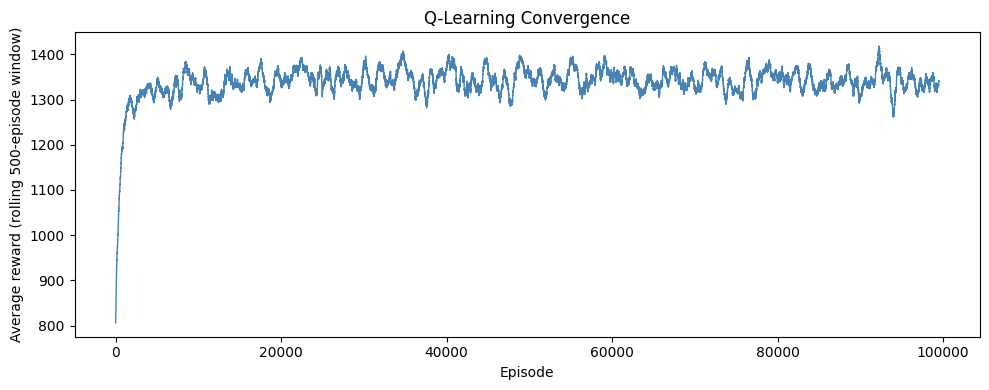

In [8]:
# ── Plot 1: Convergence ──────────────────────────
window = 500
smoothed = np.convolve(rewards_per_episode,
                       np.ones(window)/window,
                       mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smoothed, color='steelblue', linewidth=1)
plt.xlabel('Episode')
plt.ylabel(f'Average reward (rolling {window}-episode window)')
plt.title('Q-Learning Convergence')
plt.tight_layout()
plt.savefig('convergence.png', dpi=150)
plt.show()

The figure above plots the rolling 500-episode average reward over 100,000 training episodes. The agent starts with no knowledge of the environment — all Q-values are initialised to zero — and improves rapidly in the first 5,000 episodes, after which performance stabilises at approximately 1,320 reward units per 100-step episode, which corresponds to about 13.2 €/MWh per step on average. The fast initial improvement reflects the small state space: with only 33 states, the Q-table is populated quickly across episodes, and the most frequently visited state-action pairs are learned early.

The persistent fluctuation around the converged level reflects the fixed
$\varepsilon$-greedy exploration strategy: with probability $\varepsilon = 0.1$
the agent continues to take random actions even after convergence, preventing
the reward curve from flattening completely. This is a structural feature of
tabular Q-learning with fixed $\varepsilon$, not a sign of instability — the
underlying Q-table has converged, but the executed policy remains stochastic
during training.

The stabilised average reward of about 13.2 €/MWh per step can be compared directly to the
Value Iteration benchmark of 13.34 €/MWh, yielding a gap of 1.1%. This gap is economically small and is consistent with two factors: continued exploration during training and the sampling error inherent in temporal-difference learning, since Q-learning updates continuation values from realised transitions rather than exact expectations. The policy comparison in Section 4.2 shows that the remaining discrepancy is confined to a narrow boundary region, indicating that the learned policy is close to the benchmark solution.

In [9]:
# ── Average reward comparison ────────────────────
def simulate_avg(Q_table, n_steps=200000):
    np.random.seed(42)
    soc = 5
    price_idx = np.random.randint(3)
    total = 0
    for _ in range(n_steps):
        valid = get_valid_actions(soc)
        valid_idx = [np.where(actions==a)[0][0] for a in valid]
        ai = valid_idx[np.argmax([Q_table[soc, price_idx, i] for i in valid_idx])]
        action = actions[ai]
        total += get_reward(soc, price_idx, action)
        soc = int(np.clip(soc + action, 0, N))
        price_idx = np.random.choice(3, p=P[price_idx])
    return total / n_steps

avg_ql = simulate_avg(Q)
avg_vi = simulate_avg(Q_vi)
print(f"Q-Learning avg reward/step:      {avg_ql:.4f}")
print(f"Value Iteration avg reward/step: {avg_vi:.4f}")
print(f"Gap: {(1 - avg_ql/avg_vi)*100:.1f}%")

Q-Learning avg reward/step:      13.2032
Value Iteration avg reward/step: 13.3436
Gap: 1.1%


### 4.2 Optimal Dispatch Policy



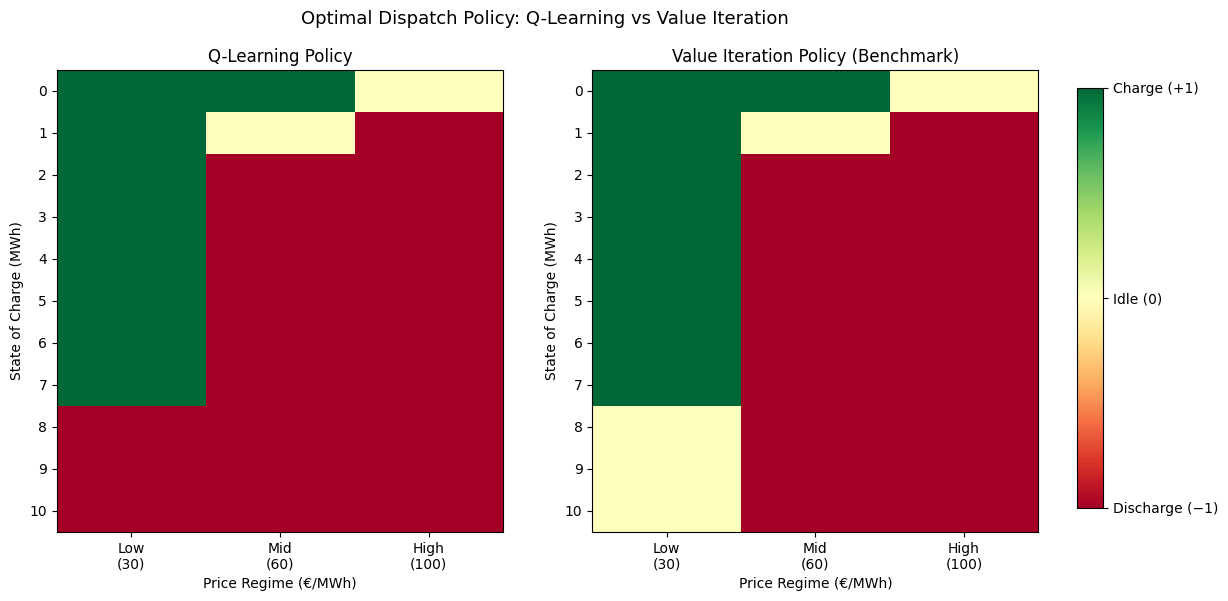

In [10]:
# ── Plot 2: Policy comparison heatmap (Q-Learning vs Value Iteration) ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, pol, title in zip(axes,
                           [policy_ql, policy_vi],
                           ['Q-Learning Policy', 'Value Iteration Policy (Benchmark)']):
    im = ax.imshow(pol, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Low\n(30)', 'Mid\n(60)', 'High\n(100)'])
    ax.set_yticks(range(N + 1))
    ax.set_yticklabels(range(N + 1))
    ax.set_xlabel('Price Regime (€/MWh)')
    ax.set_ylabel('State of Charge (MWh)')
    ax.set_title(title)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=[-1, 0, 1])
cbar.ax.set_yticklabels(['Discharge (−1)', 'Idle (0)', 'Charge (+1)'])

plt.suptitle('Optimal Dispatch Policy: Q-Learning vs Value Iteration', fontsize=13)
plt.savefig('policy_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmaps above compare the optimal dispatch policy learned by Q-learning
(left) with the benchmark policy obtained from Value Iteration (right). Each
cell shows the optimal action for a given combination of state of charge
(vertical axis) and price regime (horizontal axis).

**Overall agreement.**

The two policies are structurally identical across
almost the entire state space. Under Mid and High price regimes, both policies
prescribe discharge for nearly all SoC levels — when electricity prices are
sufficiently high, selling stored electricity is optimal regardless of the
current charge level. Under Low prices and $SoC \leq 7$, both policies
prescribe charge, reflecting the incentive to accumulate electricity when
prices are low in anticipation of higher future prices. Near the physical
boundaries, both methods also agree: at $SoC = 0$ under High prices and
$SoC = 1$ under Mid prices, the optimal action is idle, because discharging
from a near-empty battery does not generate sufficient revenue to cover the
degradation cost.

**The only disagreement: Low price, $SoC \in \{8, 9, 10\}$.**

Value Iteration
selects idle in this region; Q-learning selects discharge. The economic logic
of the Value Iteration solution is clear: when the battery is nearly full and
the current price is low, the continuation value of waiting for a Mid or High
price period exceeds the immediate discharge revenue of 28 €/MWh (= 30 − 2).
Q-learning fails to learn this.

**Why does this disagreement arise?**

Two reinforcing mechanisms explain the
discrepancy.

**1. The state (Low price, high SoC) is inherently rare under the optimal
policy.**

The simulated dispatch path in Section 4.3 confirms that SoC rarely
exceeds 8 under the greedy policy. For the battery to reach $SoC = 9$ or 10
under Low prices, the price process must remain in Low for many consecutive
steps. Given a persistence probability of 0.6, the probability of remaining
in Low for nine consecutive steps is approximately $0.6^9 \approx 0.01$. As
soon as prices transition to Mid or High, the policy switches to discharge and
SoC begins to fall. The combination of Low price and high SoC is therefore a
boundary region that the agent's own optimal behaviour makes structurally
difficult to reach during training.

**2. Q-learning's update mechanism creates an asymmetry between
immediate-reward and delayed-reward actions.**

When Q-values are initialised
to zero, the first time the agent reaches $(Low, SoC = 9)$: discharge
immediately yields 28 €, so $Q(Low, 9, \text{discharge})$ is updated to a
positive value after a single step; idle yields 0 €, so $Q(Low, 9,
\text{idle})$ remains near zero. From this point, $\varepsilon$-greedy selects
discharge 90% of the time, creating a self-reinforcing dynamic:
$Q(\text{discharge})$ is updated frequently and converges quickly, while
$Q(\text{idle})$ is only updated during the 10% exploration steps. Even within
those steps, idle is chosen with probability 1/3, and only the 40% of cases
where prices transition to Mid or High generate a positive learning signal.
The effective number of informative updates for idle in this region is
therefore extremely small over 100,000 episodes.

The fundamental difficulty is that the true value of idle is entirely a
delayed continuation value — the agent must idle, observe a favourable price
transition, then discharge at the higher price. This multi-step signal
propagates back slowly through temporal-difference updates. By contrast, the
value of discharge is revealed in a single step. This asymmetry does not arise
elsewhere: under Mid and High prices, discharge is both the correct action and
yields large immediate rewards, so the greedy policy locks onto the right
answer early. Under Low prices at low SoC, the penalty for not charging
propagates quickly across episodes. The high-SoC, Low-price region is unique
because the difference between discharge and idle is marginal rather than
catastrophic, requiring many precise updates to resolve.

**Economic significance.**

Despite this localised disagreement, the quantitative effect on overall performance is small. The average reward under Q-learning is 13.20 €/MWh, compared with 13.34 €/MWh under Value Iteration, implying a gap of only 1.1\%. The simulated path in Section 4.3 suggests that the Low-price, high-SoC region is not visited frequently under the learned greedy policy, so its contribution to the long-run average payoff appears limited. This evidence is illustrative rather than definitive, but it is consistent with interpreting the disagreement as a local approximation error in a boundary region under finite training, rather than as a structural failure of the Q-learning approach.

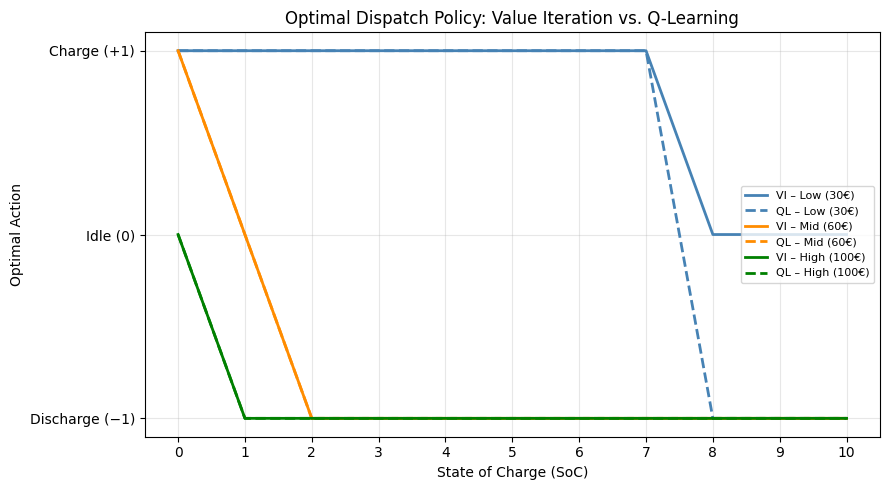

In [11]:
# ── Line chart: VI vs Q-Learning ─────────────────
price_labels = ['Low (30€)', 'Mid (60€)', 'High (100€)']
colors = ['steelblue', 'darkorange', 'green']
soc_range = np.arange(N+1)

fig, ax = plt.subplots(figsize=(9, 5))
for p in range(3):
    ax.plot(soc_range, policy_vi[:, p],
            color=colors[p], linewidth=2,
            label=f'VI – {price_labels[p]}')
    ax.plot(soc_range, policy_ql[:, p],
            color=colors[p], linewidth=2, linestyle='--',
            label=f'QL – {price_labels[p]}')

ax.set_xlabel('State of Charge (SoC)')
ax.set_ylabel('Optimal Action')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Discharge (−1)', 'Idle (0)', 'Charge (+1)'])
ax.set_xticks(soc_range)
ax.legend(loc='center right', fontsize=8)
ax.set_title('Optimal Dispatch Policy: Value Iteration vs. Q-Learning')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('policy_comparison_line.png', dpi=150)
plt.show()

**Policy comparison: line chart view.**

The line chart above provides a complementary view of the policy comparison by plotting the optimal action as a function of SoC separately for each price regime. Solid lines represent Value Iteration, while dashed lines represent Q-learning.

Under Mid and High price regimes, the VI and Q-learning lines overlap completely. Under High prices, both policies discharge for all $SoC \geq 1$ and idle at $SoC = 0$. Under Mid prices, both policies discharge for all $SoC \geq 2$ and idle at $SoC \in \{0,1\}$. This confirms that Q-learning reproduces the benchmark threshold structure in the economically most important regions of the state space.

The only visible divergence occurs in the Low-price regime. Value Iteration switches from charge to idle at $SoC = 8$, whereas Q-learning switches from charge directly to discharge at $SoC = 8$. This confirms that the disagreement is highly localised: it is confined to the high-SoC boundary under Low prices rather than reflecting a broad structural difference between the two methods.

### 4.3 Simulated Dispatch Path



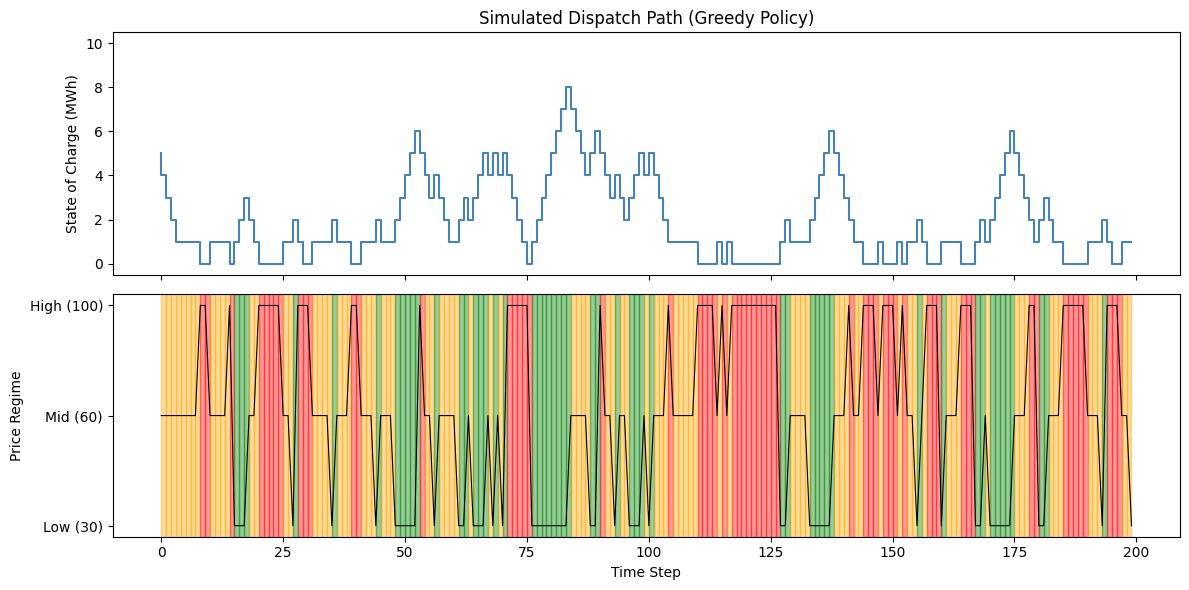

In [12]:
# ── Plot 3: Simulated dispatch path ─────────────
np.random.seed(0)
T = 200
soc_path = []
price_path = []
action_path = []

soc = 5
price_idx = 1  # start at Mid

for t in range(T):
    soc_path.append(soc)
    price_path.append(price_idx)

    valid = get_valid_actions(soc)
    valid_idx = [np.where(actions == a)[0][0] for a in valid]
    q_vals = [Q[soc, price_idx, i] for i in valid_idx]
    best_idx = valid_idx[np.argmax(q_vals)]
    action = actions[best_idx]
    action_path.append(action)

    soc, price_idx = get_next_state(soc, price_idx, action)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.step(range(T), soc_path, color='steelblue', linewidth=1.5)
ax1.set_ylabel('State of Charge (MWh)')
ax1.set_ylim(-0.5, N + 0.5)
ax1.set_title('Simulated Dispatch Path (Greedy Policy)')

price_labels = ['Low (30)', 'Mid (60)', 'High (100)']
colors = ['green', 'orange', 'red']
for t in range(T - 1):
    ax2.axvspan(t, t+1, color=colors[price_path[t]], alpha=0.4)
ax2.set_ylabel('Price Regime')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(price_labels)
ax2.plot(range(T), price_path, color='black', linewidth=0.8)
ax2.set_xlabel('Time Step')

plt.tight_layout()
plt.savefig('dispatch.png', dpi=150)
plt.show()



The figure above shows a 200-step simulated dispatch path under the learned
Q-learning policy (greedy, no exploration). The top panel shows the State of
Charge over time; the bottom panel shows the realised price regime, with
background colours indicating Low (yellow), Mid (green), and High (red) periods.

**Price arbitrage is implemented consistently.**

SoC rises during Low price
periods and falls during Mid and High price periods. This charge-low,
discharge-high pattern repeats throughout the simulation and confirms that
the learned policy captures the core economic logic of battery storage
arbitrage — without ever having been told the structure of the price
transition process.

**The battery rarely reaches full capacity.**

SoC peaks at around 8 MWh
in most cycles, rarely hitting the maximum of $N = 10$ MWh. This reflects
the stochastic price environment: Low price periods are interrupted by Mid
or High periods before the battery can fully charge, consistent with the
transition matrix diagonal of 0.6. The expected duration of a Low price
spell is $1/(1-0.6) = 2.5$ periods — too short to charge from a typical
mid-range SoC to full capacity.

**The battery frequently discharges to near-zero.**

During extended Mid or
High price periods, the agent discharges aggressively until the feasibility
constraint binds at $SoC = 0$, at which point it idles. This confirms that
the policy is not overly conservative — it extracts revenue whenever the
price justifies it, down to the physical limit.

**A note on the policy disagreement region.**

The simulated path also
provides indirect evidence for the disagreement identified in Section 4.2.
The Low price, high SoC region ($SoC \in \{8, 9, 10\}$) is visited only
briefly — whenever prices are Low, the agent charges toward high SoC, but
price transitions quickly interrupt this before SoC reaches 8. The expected
duration of a Low spell (2.5 periods) is simply too short to sustain SoC
at these levels. This confirms that the boundary disagreement between
Q-learning and Value Iteration has negligible impact on realised performance:
the contested region is not visited often enough to matter.

### 4.4 Sensitivity Analysis: Discount Factor $\beta$

In [13]:
# ── Sensitivity Analysis: varying beta ────────────────────────────────
betas_test = [0.7, 0.99]
beta_results = []
beta_policies_ql = {}
beta_policies_vi = {}

for beta_test in betas_test:

    # ── Value Iteration ──
    Q_vi_test = np.zeros((N+1, 3, 3))
    for iteration in range(10000):
        Q_old = Q_vi_test.copy()
        for soc in range(N+1):
            for price_idx in range(3):
                for ai, action in enumerate(actions):
                    valid = get_valid_actions(soc)
                    if action not in valid:
                        Q_vi_test[soc, price_idx, ai] = -1e9
                        continue
                    next_soc = int(np.clip(soc + action, 0, N))
                    r = get_reward(soc, price_idx, action)
                    continuation = sum(
                        P[price_idx, np2] *
                        max([Q_old[next_soc, np2, np.where(actions==a)[0][0]]
                             for a in get_valid_actions(next_soc)])
                        for np2 in range(3)
                    )
                    Q_vi_test[soc, price_idx, ai] = r + beta_test * continuation
        mask = Q_old > -1e9/2
        diff = np.max(np.abs((Q_vi_test - Q_old)[mask]))
        if diff < 1e-6:
            print(f"β={beta_test} | VI converged in {iteration+1} iterations")
            break

    # ── Q-learning ──
    np.random.seed(42)
    Q_test = np.zeros((N+1, 3, 3))
    for episode in range(n_episodes):
        soc = np.random.randint(0, N+1)
        price_idx = np.random.randint(0, 3)
        for step in range(100):
            valid = get_valid_actions(soc)
            valid_idx = [np.where(actions == a)[0][0] for a in valid]
            if np.random.random() < epsilon:
                action_idx = np.random.choice(valid_idx)
            else:
                q_vals = [Q_test[soc, price_idx, i] for i in valid_idx]
                action_idx = valid_idx[np.argmax(q_vals)]
            action = actions[action_idx]
            reward = get_reward(soc, price_idx, action)
            next_soc, next_price = get_next_state(soc, price_idx, action)
            next_valid = get_valid_actions(next_soc)
            next_valid_idx = [np.where(actions==a)[0][0] for a in next_valid]
            best_next_q = max([Q_test[next_soc, next_price, i]
                               for i in next_valid_idx])
            Q_test[soc, price_idx, action_idx] += alpha * (
                reward + beta_test * best_next_q - Q_test[soc, price_idx, action_idx]
            )
            soc, price_idx = next_soc, next_price

    avg_ql_test = simulate_avg(Q_test)
    avg_vi_test = simulate_avg(Q_vi_test)
    gap = (1 - avg_ql_test / avg_vi_test) * 100

    beta_policies_ql[beta_test] = get_policy(Q_test)
    beta_policies_vi[beta_test] = get_policy(Q_vi_test)

    beta_results.append({
        'beta': beta_test,
        'ql': avg_ql_test,
        'vi': avg_vi_test,
        'gap': gap
    })
    print(f"β={beta_test} | QL: {avg_ql_test:.4f} | VI: {avg_vi_test:.4f} | Gap: {gap:.1f}%")

β=0.7 | VI converged in 38 iterations
β=0.7 | QL: 0.0019 | VI: 4.1329 | Gap: 100.0%
β=0.99 | VI converged in 1643 iterations
β=0.99 | QL: 15.8690 | VI: 16.1977 | Gap: 2.0%


In [14]:
# ── Collect all policies for beta sensitivity plot ────────────────────
all_betas = [0.7, 0.95, 0.99]
all_ql = {
    0.7:  beta_policies_ql[0.7],
    0.95: policy_ql,
    0.99: beta_policies_ql[0.99]
}
all_vi = {
    0.7:  beta_policies_vi[0.7],
    0.95: policy_vi,
    0.99: beta_policies_vi[0.99]
}

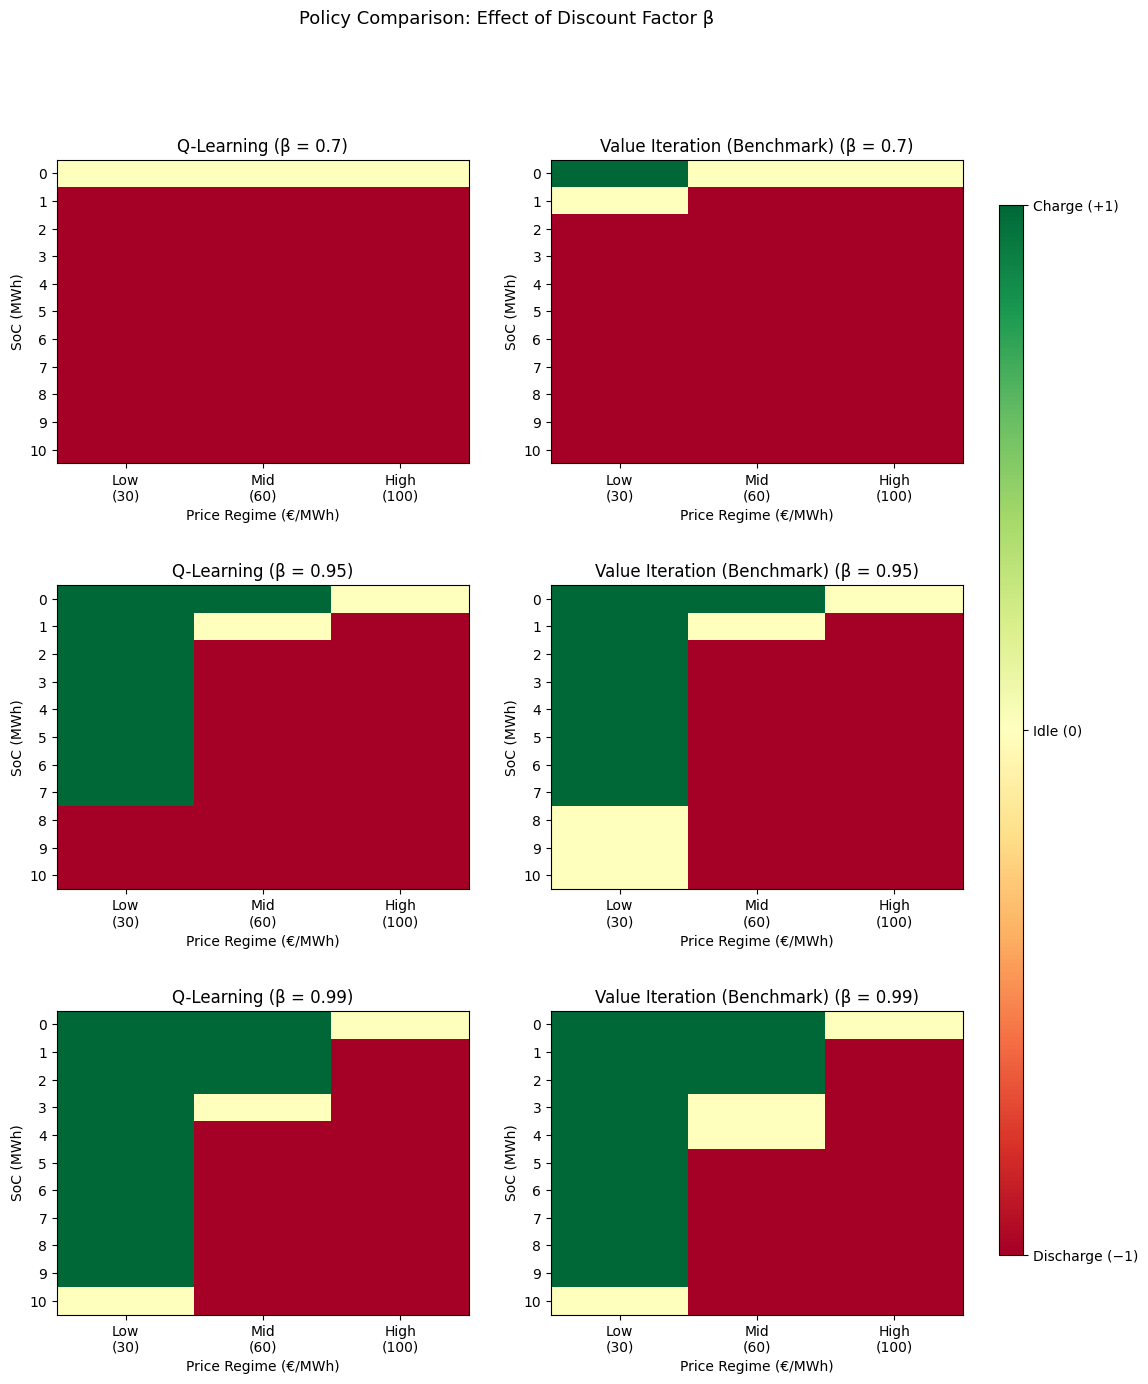

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for row, beta_val in enumerate(all_betas):
    for col, (pol, label) in enumerate([(all_ql[beta_val], 'Q-Learning'),
                                         (all_vi[beta_val], 'Value Iteration (Benchmark)')]):
        ax = axes[row, col]
        im = ax.imshow(pol, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(['Low\n(30)', 'Mid\n(60)', 'High\n(100)'])
        ax.set_yticks(range(N+1))
        ax.set_yticklabels(range(N+1))
        ax.set_xlabel('Price Regime (€/MWh)')
        ax.set_ylabel('SoC (MWh)')
        ax.set_title(f'{label} (β = {beta_val})')

fig.subplots_adjust(right=0.88, hspace=0.4)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=[-1, 0, 1])
cbar.ax.set_yticklabels(['Discharge (−1)', 'Idle (0)', 'Charge (+1)'])

plt.suptitle('Policy Comparison: Effect of Discount Factor β',
             fontsize=13, y=0.98)
plt.savefig('sensitivity_beta_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



To assess how the degree of patience shapes the optimal dispatch policy and
the Q-learning approximation quality, I re-solve the model for $\beta \in
\{0.70, 0.95, 0.99\}$, running both Value Iteration and Q-learning for each
value. The baseline is $\beta = 0.95$.

**Results.**

| $\beta$ | QL (€/MWh) | VI (€/MWh) | Gap (%) |
|:---:|:---:|:---:|:---:|
| 0.70 | 0.00* | 4.13 | 100.0% |
| 0.95 (baseline) | 13.20 | 13.34 | 1.1% |
| 0.99 | 15.87 | 16.20 | 2.0% |

*QL reward at $\beta = 0.70$ is 0.0019 €/MWh, rounded to zero. The near-zero
value reflects a degenerate policy in which the agent discharges to $SoC = 0$
early in each simulation and subsequently idles for the remainder, generating
negligible revenue.

VI required 38 iterations to converge at $\beta = 0.70$ and 1,643 iterations
at $\beta = 0.99$, compared to 314 at the baseline. This pattern is consistent
with the standard result that a higher discount factor slows contraction of the
Bellman operator, since the contraction modulus is $\beta$ itself.

**Policy patterns.**

The heatmaps below visualise the resulting policy
functions across all six $(\beta, \text{method})$ combinations. Each cell
shows the optimal action — Charge $(+1)$, Idle $(0)$, or Discharge $(-1)$ —
as a joint function of SoC ($y$-axis) and price regime ($x$-axis).

*$\beta = 0.70$.* Both VI and QL prescribe discharge across the vast majority of states. The policy is therefore strongly myopic: because future payoffs are heavily discounted, the continuation value $\beta \cdot V(s')$ carries little weight in the Bellman equation, so the incentive is to monetise stored electricity immediately rather than preserve it for future price increases. VI nonetheless identifies a minimal non-discharge region under Low prices: it charges at $SoC = 0$ and idles at $SoC = 1$, reflecting the fact that some replenishment is necessary to sustain any future revenue stream. Q-learning misses this structure and instead learns an almost purely discharge-oriented policy, which drives the battery to $SoC = 0$ early in the simulation and leaves little scope for subsequent revenue generation. As a result, its average reward is essentially zero, producing a gap of 100\%.

*$\beta = 0.95$ (baseline).* The policy exhibits the canonical three-region structure: charge at Low prices when the battery is not full, idle at boundary states, and discharge at Mid and High prices. Economically, this reflects a balanced intertemporal trade-off. Future payoffs matter enough to make storage valuable, but not so much that the agent delays discharge excessively. The battery is therefore used as an arbitrage device in the standard sense: electricity is bought when prices are low and sold when prices are high, while idle actions appear only where immediate discharge is not worthwhile relative to continuation value. Q-learning closely mirrors the VI benchmark, with only a local discrepancy in the Low-price, high-SoC boundary region, yielding a gap of 1.1\%.

*$\beta = 0.99$.* The agent becomes substantially more patient. The charging region expands markedly: under Low prices, both VI and QL charge up to high SoC levels (around $SoC = 8$), and a broader idle band appears under Mid prices for low-to-mid SoC states. Economically, this reflects the stronger intertemporal value of stored electricity when $\beta$ is high. Because future payoffs are discounted only slightly, the opportunity cost of discharging too early increases: selling today at a Mid or Low price implies forgoing the possibility of selling tomorrow at a High price. As a result, the model assigns greater value to inventory preservation, which expands the charging region and creates a wider idle band between charging and discharging. Although the qualitative policy pattern learned by Q-learning remains close to the Value Iteration benchmark, the reward gap increases to 2.0\%, compared with 1.1\% in the baseline case. This suggests that when continuation value becomes more important, even small residual policy differences can translate into larger payoff differences.

**Economic interpretation.**

The discount factor governs the intertemporal trade-off between current and future revenue. In the Bellman equation,
$$
V(s) = \max_{a \in \mathcal{A}(s)} \left[ r(s,a) + \beta \sum_{s'} p(s' \mid s,a)\,V(s') \right],
$$
a lower $\beta$ reduces the weight placed on continuation value and therefore makes the dispatch problem more myopic: the agent tends to sell immediately rather than preserve energy for future price spikes. A higher $\beta$, by contrast, increases the option value of storage, expands the charging region, and creates a more pronounced idle zone between charging and discharging decisions. The increase in benchmark VI revenue from 4.13 to 13.34 to 16.20 €/MWh as $\beta$ rises confirms that patience is a central driver of arbitrage value in this storage model.

**The $\beta = 0.70$ failure of Q-learning.**

The 100% gap at $\beta = 0.70$
is not a sign that the policy is trivially easy to learn — it reflects a
subtle exploration-exploitation failure specific to low-discount environments.
With $\beta = 0.70$, Q-values are numerically very small, so the signal
distinguishing a good action from a bad one is weak. Q-learning learns to
discharge aggressively and never learns to charge: once the battery reaches
$SoC = 0$, it can no longer discharge and earns nothing, driving the long-run
average reward to zero. VI correctly identifies that charging at low prices
when $SoC \approx 0$ is necessary to sustain any revenue stream. This
underscores a known limitation of tabular Q-learning: when the reward signal
is small in magnitude, the algorithm requires substantially more episodes or
more careful hyperparameter tuning — such as optimistic Q-table initialisation
— to escape degenerate policies.

## 5. Discussion and Improvements

### 5.1 What we learn from the model

The model delivers a clear economic conclusion: a battery storage operator
facing stochastic electricity prices should implement a threshold-based
arbitrage strategy — charge when prices are low, discharge when prices are
high, and idle only when physical constraints bind or when the continuation
value of waiting exceeds the immediate discharge revenue. The degradation cost
$c_{deg} = 2$ €/MWh plays an important disciplining role: without it, the
agent would cycle the battery at every step regardless of the price spread,
which is economically unrealistic and physically damaging.

The precise thresholds are economically interpretable. Under Mid prices, both
policies agree: the agent idles when the battery is nearly empty
($\text{SoC} \leq 1$ MWh) and discharges otherwise, since the net revenue of
58 €/MWh after degradation costs justifies selling at all but the lowest
charge levels.

Under Low prices, the two policies diverge at high SoC. Both VI and QL charge
for $\text{SoC} \leq 7$ MWh, where the continuation value of a fuller battery
outweighs the immediate discharge revenue of 28 €/MWh. At $\text{SoC} \geq 8$
MWh, however, VI switches to idle — correctly recognising that the battery is
already well-stocked and that waiting for a higher price regime dominates
selling now. Q-learning instead prescribes discharge at these states, having
systematically underestimated the continuation value of idling due to
exploration asymmetry: discharge yields an immediate positive reward that
dominates early Q-table updates, while idle's true long-run value requires
multi-step feedback propagation that finite training does not fully resolve.
Despite this disagreement, the performance impact is small (gap of 1.1%),
because high-SoC states under Low prices are structurally rare given the
Low→Low persistence in the price transition matrix.

The sensitivity analysis in Section 4.4 further reveals that patience is a
core driver of arbitrage value, because storage is fundamentally a real
option: its value derives from the right — but not the obligation — to
shift revenue across time, and that right is worth less the more heavily
future payoffs are discounted. A myopic agent ($\beta = 0.70$) illustrates
the extreme case: the QL policy degenerates almost entirely to discharge,
earning essentially zero average revenue (€0.00/MWh) — a 100% gap relative
to the VI benchmark of €4.13/MWh. Even the VI benchmark at this low $\beta$
recovers only a fraction of the baseline reward, underscoring that patience
is a structural prerequisite for meaningful storage arbitrage.

The Q-learning agent recovers 98.9% of the Value Iteration benchmark reward
(€13.20 vs €13.34/MWh) at the baseline $\beta = 0.95$, without ever
observing the price transition matrix $P$. This has a natural economic
interpretation: the arbitrage opportunity is encoded in the price path
itself, so an agent with sufficient market experience can learn a
near-optimal dispatch rule even under incomplete information about the
underlying price process — a realistic constraint in electricity markets,
where transition probabilities are non-stationary and difficult to estimate.

### 5.2 Strengths of the chosen method

**Model-free learning.**

Q-learning requires no prior knowledge of the price
transition probabilities. In practice, electricity price dynamics are complex
and non-stationary; a model-free agent can in principle adapt to changing
market conditions without requiring a re-estimated transition model.

**Exact representation.**

The state space is small (33 states) and fully
discrete, so the Q-table represents $Q^*$ exactly without approximation error.
The choice of $N = 10$ produces a rich enough policy structure to be
analytically interesting — the three price regimes generate qualitatively
different behaviour across SoC levels — while remaining small enough for
tabular methods to handle without the curse of dimensionality.

**Convergence guarantees.**

Tabular Q-learning converges to $Q^*$ under
standard conditions: all state-action pairs must be visited sufficiently often
(ensured by $\varepsilon$-greedy exploration) and the learning rate $\alpha$
must be sufficiently small. Both conditions are satisfied here, and convergence
is confirmed empirically by the reward curve in Section 4.1.

**Interpretability.**

The learned policy is stored as a simple lookup table
and can be inspected directly. The heatmaps in Section 4.2 make the dispatch
logic immediately readable, which is valuable for communicating results to
non-technical stakeholders.

### 5.3 Weaknesses and limitations

**Exploration asymmetry under fixed $\varepsilon$.**

As identified in Section
4.2, Q-learning with a fixed $\varepsilon$-greedy policy creates a structural
asymmetry: actions with high immediate rewards (discharge) are updated far more
frequently than actions whose value depends on long signal propagation chains
(idle). This causes the idle action at Low price, high SoC to be systematically
underestimated under finite training, producing the localised policy
disagreement observed in Section 4.2.

**Sensitivity to $\beta$.**

The sensitivity analysis reveals a dramatic
failure at $\beta = 0.70$: Q-learning earns essentially zero reward while VI
earns 4.13 €/MWh, a gap of 100%. When $\beta$ is low, Q-values are
numerically small and the signal distinguishing good from bad actions is weak.
Q-learning never learns to charge, the battery depletes to $SoC = 0$, and the
agent idles indefinitely. This underscores that tabular Q-learning with fixed
hyperparameters is not robust across all discount environments — careful
tuning or optimistic initialisation may be required for low-$\beta$ settings.

**Simplified price process.**

The three-regime Markov chain is a strong
simplification of real electricity price dynamics, which exhibit intraday
seasonality, negative prices, and fat-tailed spike distributions. All
parameter values are stylised rather than estimated from data.

**Discrete action space.**

Restricting actions to $\{-1, 0, +1\}$ MWh per
period rules out partial charging or discharging, which may cause the agent
to miss finer arbitrage opportunities.

**No degradation dynamics.**

The degradation cost $c_{deg}$ is a fixed
per-cycle cost. In reality, degradation depends on depth of discharge and
cumulative cycles, reducing battery capacity over time. Ignoring this may
overestimate long-run profitability.

### 5.4 Why not SARSA?

SARSA is on-policy: it learns the action-value function of the $\varepsilon$-greedy policy actually executed during training, rather than the value of the fully greedy policy. With fixed $\varepsilon > 0$, SARSA therefore converges to a policy that permanently incorporates exploration noise. Q-learning, by contrast, is off-policy: it bootstraps using $\max_{a'} Q(s', a')$ and is designed to move toward the optimal greedy action-value function even when exploration is used during learning.

This distinction matters here because the objective of the exercise is to recover an approximately optimal dispatch policy for the battery, not the value of an exploratory training policy. In that sense, Q-learning is the more natural algorithmic choice in this stylised setting. At the same time, in the present finite-sample implementation, it is best interpreted as an empirical approximation to $Q^*$ rather than as a literal proof of exact asymptotic convergence.

### 5.5 Concrete improvements and extensions

**Decaying $\varepsilon$ schedule.**

Replacing fixed $\varepsilon = 0.1$ with
a schedule that starts high and decays toward zero as training progresses would
ensure broad state coverage early in training while allowing the policy to
converge to near-greedy behaviour later. This directly addresses the
exploration asymmetry in Section 5.3 and would likely close the remaining
1.1% gap versus Value Iteration. It would also help stabilise learning at
low $\beta$, where the weak reward signal requires more systematic exploration
to escape degenerate policies.

**Richer price process.**

Replacing the three-state Markov chain with a
continuous AR(1) or regime-switching model calibrated to SMARD hourly data
would better capture real electricity price dynamics, including intraday
seasonality and price spikes. This would require moving from tabular
Q-learning to function approximation such as semi-gradient SARSA or a deep
Q-network (DQN), as the state space would become continuous.

**Continuous SoC and actions.**

Extending the state space to continuous
$SoC \in [0, 10]$ and allowing partial charge/discharge actions would
eliminate discretisation error and bring the model closer to real battery
operation. This is a natural application for deep reinforcement learning
methods.

**Endogenous degradation.**

Modelling battery capacity as a second state
variable that decays with usage would allow the agent to trade off short-run
arbitrage revenue against long-run capacity preservation — a more realistic
and economically richer problem that would substantially increase the
complexity of the Bellman equation.

## 6. AI/LLM Usage

I used Claude (Anthropic) as an AI assistant throughout the preparation of
this notebook. Specifically, I used it for the following purposes:

**Model design.**

I discussed the MDP formulation with Claude extensively,
including the choice of state variables, action space, reward function, and
transition matrix structure. This included an iterative back-and-forth on
whether SoC should enter the reward function directly (conclusion: no — it
only constrains feasible actions, analogous to the pricing game in Exercise
28 of the course), and the choice between infinite-horizon and finite-horizon
formulations (conclusion: infinite-horizon, benchmarked against Value
Iteration).

**Conceptual clarification.**

I used Claude to clarify conceptual questions
about reinforcement learning, including the distinction between Q-learning and
SARSA, the difference between on-policy and off-policy learning, the role of
$\varepsilon$-greedy exploration versus the max operator in the Q-learning
update, and the convergence properties of tabular Q-learning. I also used
Claude to work through why the policy disagreement between Q-learning and
Value Iteration appears specifically at Low price, high SoC — including
ruling out maximisation bias as the explanation and identifying exploration
asymmetry as the correct cause. For the sensitivity analysis, Claude helped
me interpret the $\beta = 0.70$ failure of Q-learning and connect it to the
weak reward signal problem in low-discount environments.

**Code.**

Claude provided initial code templates for the environment functions,
Q-learning main loop, Value Iteration benchmark, sensitivity analysis loops,
and all visualisations. I ran each code block, checked the outputs against
expected values, and debugged errors. I also made independent decisions about
training parameters (episode count, step count) based on convergence
diagnostics.

**Text production.**

Claude drafted the written sections of this notebook,
including the Introduction, Economic Model, Solution Method, Results, and
Discussion. I reviewed each section, corrected errors, updated numbers after
each run, and adjusted the framing where needed.

**Parameter justification.**

Claude helped me justify the choice of parameter
values, including the transition matrix structure, degradation cost, and
discount factor, by connecting them to course exercises and real-world
electricity market context.

**Most helpful use: debugging the policy disagreement.**

The most valuable use of AI was in working through why Q-learning and Value
Iteration disagree at Low price, high SoC. The reasoning went through several
stages. We first considered maximisation bias as a candidate explanation —
the idea that Q-learning's max operator systematically overestimates Q-values.
However, this was ruled out: if maximisation bias were the cause, the
disagreement would appear first at Mid prices where Q-value differences between
actions are smallest, not at Low prices where they are largest.

We then looked at the simulated dispatch path, which showed that SoC rarely
exceeds 8 under the greedy policy. This suggested that the high-SoC, Low-price
region might simply be visited infrequently. Computing the probability of
remaining in Low prices for many consecutive steps — approximately $0.6^9
\approx 0.01$ — confirmed that this boundary region is structurally rare under
the optimal policy.

Finally, we analysed why the same issue does not arise under Mid and High
prices. Under those regimes, discharge yields large immediate rewards (58 and
98 €/MWh respectively), making its Q-value clearly dominant over alternatives
from early in training. Under Low prices, however, discharge yields only 28
€/MWh — still positive, but close enough to idle's delayed value that the
distinction requires many precise updates to resolve. Idle's true value depends
entirely on a multi-step signal chain: the agent must idle, wait for a
favourable price transition, then discharge at the higher price. This chain is
slow to propagate through temporal-difference updates, and idle is only visited
during 10% exploration steps to begin with. The combination of low visit
frequency and slow signal propagation explains why Q-learning systematically
underestimates idle in this region. Working through this reasoning step by step,
and correcting AI explanations that were initially incomplete or incorrect,
deepened my understanding of how Q-learning's update mechanism interacts with
the specific structure of this problem.

**Verification of AI-generated content.**

I verified AI-generated code by running sanity checks on each function before
proceeding (e.g. confirming that `get_reward(5, 2, -1) = 98`,
consistent with the formula $r = -p \cdot a - c_{deg}|a|$). I cross-checked
all mathematical expressions against the lecture notes and Sutton \& Barto
(2018). AI-generated text was reviewed and corrected where notation was
inconsistent or numbers were outdated after re-running the model.

I take full responsibility for the content of this notebook. All results were
produced and verified by me, and the submitted work reflects my own
understanding of the material.


## 7. References

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction*
(2nd ed.). MIT Press. Available at: http://incompleteideas.net/book/the-book.html

Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*,
8(3–4), 279–292.

Bundesnetzagentur. (2025). *SMARD Strommarktdaten* [Electricity market data].
Available at: https://www.smard.de

Trede, M., Lingens, J., & Haastert, S. (2025). *Lecture notes and exercise
sets: Dynamic Optimisation and Reinforcement Learning*, Winter Term 2025/2026.
University of Münster.